## Loading Data

In [76]:
import numpy as np
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/twitter-data/master/twitter4000.csv", encoding="latin1")
df.sample(5)

,twitts,sentiment
952,off to the gym -I am really forcing myself to ...,0
2077,@shararee I normally mix all my cereals. that ...,1
1165,The dog got into a RAID Outdoor Ant Spike this...,0
405,@kooljaek you had a great trip tho. I envy you...,0
935,"@bitofwhimsy I'm sorry, my 5yo is that way abo...",0


In [77]:
df.shape, df.isna().sum().any(), df.duplicated().sum().any()

((4000, 2), np.False_, np.True_)

In [78]:
df.drop_duplicates(inplace=True)
df.duplicated().sum().any()

np.False_

## Creating Features  

In [79]:
from spacy.lang.en.stop_words import STOP_WORDS as stopwords
import re

def count_fun(df, col):
    df["words_count"] = df[col].apply(lambda x: len(str(x).split()))
    df["chars_count"] = df[col].apply(lambda x: len("".join(str(x).split())))
    df["avg_words_len"] = df["chars_count"] / df["words_count"]
    df["hashtags_count"] = df[col].apply(lambda x: len([t for t in x.split() if t.startswith("#")]))
    df["mentions_count"] = df[col].apply(lambda x: len([t for t in x.split() if t.startswith("@")]))
    df["stop_words_count"] = df[col].apply(lambda x: len([t for t in x.split() if t in stopwords]))
    df["num_digits_count"] = df[col].apply(lambda x: sum(n.isdigit() for n in x.split()))
    df["upper_case_count"] = df[col].apply(lambda x: len([t for t in x.split() if t.isupper()]))
    df["emails_count"] = df[col].apply(lambda x: len(re.findall(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9]+\.[a-zA-Z]{2,}", x)))
    df["urls_count"] = df[col].apply(lambda x: len(re.findall(r"(?:https?|http|ftp|ssh)://\S+", x)))

    return df

In [80]:
count_fun(df, "twitts")
df.sample(5)

,twitts,sentiment,words_count,chars_count,avg_words_len,hashtags_count,mentions_count,stop_words_count,num_digits_count,upper_case_count,emails_count,urls_count
3120,"@EmmoLei Oh that's great, enjoy",1,5,27,5.400000,0,1,0,0,0,0,0
2416,@chrisdrackett My new portfoliodesign will mak...,1,12,73,6.083333,0,1,4,0,0,0,0
1152,@stilettojungle thanks for the bracelet sale p...,0,15,97,6.466667,0,1,4,0,0,0,1
2691,i think the awards are second . because most o...,1,23,93,4.043478,0,0,13,0,2,0,0
879,NNOOOO!!! my hair poofed! but the color looks...,0,15,72,4.800000,0,0,6,0,1,0,0


## Conteracion Expansion

In [81]:
conteractions= {
'could’ve': 'could have',
'he’d': 'he had, he would',
'he’ll': 'he will',
'he’s': 'he has, he is',
'here’s': 'here is',
'how’d': 'how did, how would',
'how’ll': 'how will',
'how’re': 'how are',
'how’s': 'how has, how is',
'i’d': 'i had, i would',
'i’ll': 'i will',
'i’m': 'i am',
'im': 'i am',
'i’ve': 'i have',
'it’d': 'it had, it would',
'it’ll': 'it will',
'it’s': 'it has, it is',
'let’s': 'let us',
'might’ve': 'might have',
'must’ve': 'must have',
'she’d': 'she had, she would',
'she’ll': 'she will',
'she’s': 'she has, she is',
'should’ve': 'should have',
'somebody’s': 'somebody has, somebody is',
'someone’s': 'someone has, someone is',
'something’s': 'something has, something is',
'that’d': 'that would',
'that’ll': 'that will',
'that’s': 'that has, that is',
'there’s': 'there has, there is',
'there’re': 'there are',
'these’ll': 'these will',
'these’re': 'these are',
'they’d': 'they had, they would',
'they’ll': 'they will',
'they’re': 'they are',
'they’ve': 'they have',
'this’ll': 'this will',
'this’s': 'this has, this is',
'those’ll': 'those will',
'to’ve': 'to have',
'we’d': 'we had, we would',
'we’ll': 'we will',
'we’re': 'we are',
'we’ve': 'we have',
'what’d': 'what did',
'what’ll': 'what will',
'what’re': 'what are',
'what’s': 'what has, what is',
'what’ve': 'what have',
'when’d': 'when did',
'when’s': 'when has, when is',
'where’d': 'where did',
'where’ll': 'where will',
'where’re': 'where are',
'where’s': 'where has, where is',
'where’ve': 'where have',
'which’s': 'which has, which is',
'who’d': 'who did, who had, who would',
'who’ll': 'who will',
'who’re': 'who are',
'who’s': 'who has, who is',
'who’ve': 'who have',
'why’d': 'why did',
'why’re': 'why are',
'why’s': 'why has, why is',
'would’ve': 'would have',
'you’d': 'you had, you would',
'you’ll': 'you will',
'you’re': 'you are',
'you’ve': 'you have',
'u': 'you',
'ur': 'you are',
'n': 'and',
"aren’t": "are not",
"can’t": "can not",
"couldn’t": "could not",
"didn’t": "did not",
"doesn’t": "does not",
"don’t": "do not",
'dont': 'do not',
"hadn’t": "had not",
"hasn’t": "has not",
"haven’t": "have not",
"isn’t": "is not",
"mustn’t": "must not",
"shouldn’t": "should not",
"wasn’t": "was not",
"weren’t": "were not",
"won’t": "will not",
"wouldn’t": "would not"
}

for i,key in enumerate(list(conteractions.keys())):
    new_key = key.replace("’", "'")
    if new_key != key:
        conteractions[new_key] = conteractions.pop(key)

In [82]:
df['twitts'] = df.twitts.apply(lambda x: str(x).lower())

def to_exp(x):
    for t in x.split():
        if t in list(conteractions.keys()):
            x = x.replace(t, conteractions[t])
    return x

df['twitts'] = df.twitts.apply(lambda x: to_exp(x))

## Text Cleaning

In [83]:
from bs4 import BeautifulSoup

def clean_fun(df, col):
    df[col] = df[col].apply(lambda x: re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9]+\.[a-zA-Z]{2,}", "", x))  # remove emails
    df[col] = df[col].apply(lambda x: re.sub(r"(?:https?|http|ftp|ssh)://\S+", "", x))                 # remove urls
    df[col] = df[col].apply(lambda x: BeautifulSoup(x, "lxml").get_text().strip())                     # remove html tags
    #df[col] = df[col].apply(lambda x: ' '.join([t for t in x.split() if t not in stopwords]))
    df[col] = df[col].apply(lambda x: re.sub(r"[^\w ]+", "", x))                                       # remove special charaters
    df[col] = df[col].apply(lambda x: re.sub(r"\brt\b", "", x))                                        # remove re-tweets
    df[col] = df[col].apply(lambda x: " ".join(x.split()))                                             # remove multiple spaces

    return df

In [84]:
clean_fun(df, "twitts")
df.sample(5)

,twitts,sentiment,words_count,chars_count,avg_words_len,hashtags_count,mentions_count,stop_words_count,num_digits_count,upper_case_count,emails_count,urls_count
980,bebeld thank yoooou bff 3 ily so much too you ...,0,27,103,3.814815,0,1,7,0,2,0,0
3052,xabbeyfanx nopeee and good i guess i just talk...,1,13,59,4.538462,0,1,7,0,0,0,0
3483,hopefully getting some sleep tonightmaybe brea...,1,16,90,5.625000,0,0,3,0,1,0,0
3142,long work week but i will be enjoying my weeke...,1,23,115,5.000000,0,0,8,0,0,0,0
753,working out my relationship issues with kaze i...,0,13,69,5.307692,0,0,5,0,0,0,0


In [85]:
num_cols = df.select_dtypes(include='number').drop(['sentiment'], axis=1)
target = df['sentiment']
num_cols.corrwith(target)

words_count        -0.068971
chars_count         0.008767
avg_words_len       0.182312
hashtags_count      0.040282
mentions_count      0.167502
stop_words_count   -0.104169
num_digits_count   -0.030588
upper_case_count   -0.052942
emails_count        0.015817
urls_count          0.071461
dtype: float64

In [86]:
import unicodedata

def accent_op(x):
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8", "ignore")
    return x

df['twitts'] = df.twitts.apply(lambda x: accent_op(x))                                                # accented removal                                              

In [87]:
# Common words removal..

text = ' '.join(df['twitts'])
text = text.split()
freq_comm = pd.Series(text).value_counts().sort_values(ascending=False)
f15 = freq_comm.head(15).index.tolist()
r10 = freq_comm.tail(15).index.tolist()

df['twitts'] = df.twitts.apply(lambda x: ' '.join([t for t in x.split() if t not in f15]))
df['twitts'] = df.twitts.apply(lambda x: ' '.join([t for t in x.split() if t not in r10]))

In [88]:
import spacy

nlp = spacy.load("en_core_web_sm")
def to_root(x):
    x = str(x)
    x_list = [] 
    doc = nlp(x)
    for token in doc:
        lemma = token.lemma_
        if lemma=="-PRON-" or lemma=="be":
            lemma = token.text
        x_list.append(lemma.lower())
    return " ".join(x_list)


df['twitts'] = df.twitts.apply(lambda x: to_root(x))

## Data Splitting

In [89]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

X = df.drop(['sentiment'], axis=1)
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train_text, X_test_text = X_train['twitts'], X_test['twitts']
X_train_num, X_test_num = X_train.drop(['twitts'], axis=1), X_test.drop(['twitts'], axis=1)

#### **Tokenizaion technique:** 
>- *can created manually by using **TextBlob().words***
>- *can created automatically by with **Vectorization technique***
###### ===========================================================================

#### **Vectorization technique:**
>- ***Bag of Words** (BoW) using **CountVectorizer***
>- ***TF-IDF** using **TfidfVectorizer***
>- ***Words Embedding***
##### *from **scikit-learn of feature extraction calling text library***

###### ===========================================================================

#### **Embedding technique:**
>- ***Word2Vec***
>- ***GloVe***
>- ***FastText***
- *Embedding is a subset of vectorization but more smart and understanding sequential texts.*
- *Using for modern algorithms like BERT, RoBERTa.*
###### ===========================================================================

## Tokenization - Vectorization

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf.fit_transform(X_train_text)
X_test_vec = tfidf.transform(X_test_text)

In [91]:
from scipy.sparse import hstack

X_train = hstack([X_train_vec, X_train_num])
X_test = hstack([X_test_vec, X_test_num])

In [92]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report, auc, roc_curve


CatB = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=False)
LR = LogisticRegression(penalty='elasticnet',solver='saga',l1_ratio=.7)
RF = RandomForestClassifier(n_estimators=50)
clf = VotingClassifier(estimators=[('cbc', CatB), ('xgb', XGBClassifier()),
                                   ('rf', RF), ('lgb', LGBMClassifier())], voting='hard')   # soft: for probability average..

folds = 5
cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
Eva_rep = cross_validate(estimator=CatB, X=X_train, y=y_train, cv=cv, scoring=['accuracy', 'recall', 'f1']) 
pd.DataFrame(Eva_rep)

,fit_time,score_time,test_accuracy,test_recall,test_f1
0,8.128757,0.015433,0.710938,0.724458,0.716692
1,7.939553,0.017092,0.701562,0.724458,0.710167
2,8.051265,0.012814,0.715625,0.730650,0.721713
3,8.065864,0.015391,0.697966,0.714286,0.704441
4,7.928436,0.015705,0.718310,0.770898,0.734513


In [93]:
CatB.fit(X_train, y_train)
y_pred = CatB.predict(X_test)
print(f"Classification report:\n{classification_report(y_test, y_pred)}")

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       415
           1       0.69      0.72      0.70       385

    accuracy                           0.71       800
   macro avg       0.71      0.71      0.71       800
weighted avg       0.71      0.71      0.71       800



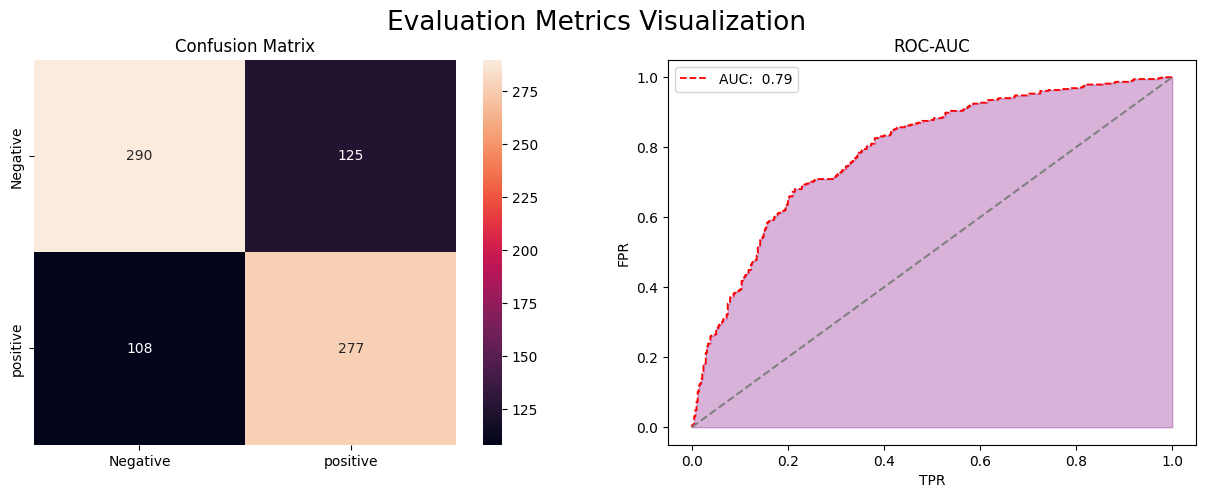

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


fig,ax = plt.subplots(1, 2, figsize=(15,5))

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, ax=ax[0], fmt="d", xticklabels=['Negative','positive'], yticklabels=['Negative','positive'])
ax[0].set_title("Confusion Matrix")

y_pred_proba = CatB.predict_proba(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba[:,1])
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='red', linestyle='dashed', lw=1.3, label=f"AUC: {roc_auc: .2f}")
plt.fill_between(fpr, tpr, alpha=0.3, color='purple')
ax[1].plot([0,1], [0,1], linestyle='dashed', color='grey')
ax[1].set_xlabel('TPR')
ax[1].set_ylabel('FPR')
ax[1].set_title("ROC-AUC")
ax[1].legend()

plt.suptitle("Evaluation Metrics Visualization", fontsize=19)
plt.show()